# Opdracht 1.1: Beeldherkenning

We gaan aan de slag met de '*Hello World*' van neurale netwerken: het herkennen van de handgeschreven cijfers van de [MNIST dataset](http://yann.lecun.com/exdb/mnist/). Deze dataset bestaat uit een trainset van 60.000 plaatjes met cijfers en een testset van nog eens 10.000 plaatjes.
- De trainset wordt gebruikt om het model te trainen.
- De testset wordt gebruikt om de prestatie van het model te testen.

De plaatjes zien er als volgt uit:<br>
<a title="Josef Steppan, CC BY-SA 4.0 &lt;https://creativecommons.org/licenses/by-sa/4.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:MnistExamples.png"><img width="512" alt="MnistExamples" src="https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png"></a>

**De opdracht is om de juiste lagen voor dit netwerk te maken zodanig dat het model de geschreven cijfers goed voorspelt.**



## 1. Installatie
We hebben hier een paar modules voor nodig, deze worden hieronder geïnstalleerd.

In [3]:
# @title 1.1. Installeer modules
!pip install numpy tensorflow matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Modules importeren
Daarnaast moeten deze modules worden geïmporteerd.

In [4]:
# @title 2.1. Importeer modules
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import to_categorical


## 3. Definieer functies
We hebben een aantal functies gemaakt die een neuraal netwerk traint om handgeschreven cijfers te herkennen en een om de effectiviteit van datzelfde model te testen.<br><br>
Als je het leuk vindt, kun je deze code analyseren. <b>Dit is echter niet nodig voor het maken van deze oefening.</b>



In [5]:
# @title 3.1. Definieer functies
def train_model(input_size, hidden_size, output_size, x_train, y_train):
  x_train = x_train.astype('float32') / 255
  x_train = x_train.reshape(-1, input_size)
  y_train = to_categorical(y_train, output_size)

  model = Sequential([
      Input(shape=(input_size,)),
      Dense(hidden_size, activation='relu'),
      Dense(output_size, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  model.fit(x_train, y_train, epochs=1, batch_size=32)

  return model

def test_model(model, input_size, output_size, x_test, y_test):
  x_test = x_test.astype('float32') / 255
  x_test_flat = x_test.reshape(-1, input_size)
  y_test = to_categorical(y_test, output_size)

  test_loss, test_acc = model.evaluate(x_test_flat, y_test)
  print()
  print(f'Modelprestatie: {test_acc:.4f}')

  predictions = model.predict(x_test_flat)

  print()
  print(f'3 verkeerde voorspellingen:')
  count = 0
  for i in range(len(y_test)):
    if count >= 3:
      break

    if np.argmax(y_test[i]) != np.argmax(predictions[i]):
      count += 1
      plt.imshow(x_test[i], cmap='gray')
      plt.title(f'Voorspeld: {np.argmax(predictions[i])}, correct: {np.argmax(y_test[i])}')
      plt.show()

## 4. MNIST laden en tonen
Onderstaande code laadt de mnist dataset in vier onderdelen:


1.   x_train: De inputplaatjes waar het model op getraind wordt.
2.   y_train: De outputwaarden (de waarde van de getallen) waar het model op getraind wordt.
3.   x_test: de inputplaatjes waarmee de prestatie van het model getest wordt.
4.   y_test: de outputwaarden waarmee de prestatie van het model getest wordt.

Na het inladen worden alle grijswaardenwaarden alle pixels van het allereerste plaatje geprint.
<b>
- Welk cijfer staat hier?
- Pas de code aan om andere cijfers te tonen.</b>


In [6]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

mat = x_train[4]
col_maxes = [max([len(("{:g}").format(x)) for x in col]) for col in mat.T]
for x in mat:
    for i, y in enumerate(x):
        print(("{:3}").format(y), end="  ")
    print("")

  0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0  
  0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0  
  0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0  
  0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0  
  0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0  
  0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0  
  0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0  
  0    0    0

## 5. Het neurale netwerk
Om ons model te kunnen maken, moeten we de drie lagen van ons netwerk bepalen:


1.   De inputlaag: hier stoppen we de grijswaarde van elke pixel van het plaatje in.
2.   De verborgen laag: hierdoor begrijpt het netwerk complexe structuren.
3.   De outputlaag: hier wordt per cijfer bepaald of het handgeschreven plaatje deze waarde heeft.

## 6. De inputlaag
Als eerste moeten we bepalen hoe groot de inputlaag moet worden om de plaatjes te kunnen klassificeren.

**Opdracht 1.1: Hoe groot moet de inputlaag zijn?**

Tip: de inputlaag moet precies groot genoeg zijn om de grijswaarden van een plaatje te bevatten.

Tip 2: wanneer dit getal onjuist is, zal het trainen en testen van het model een foutmelding geven

In [14]:
input_size = 784 # Een input_size van 1 is niet correct.. Wat wel?

## 7. De outputlaag
Daarna moeten we bepalen hoe groot de outputlaag moet worden om het juiste aantal klassen te kunnen voorspellen.

**Opdracht 1.2: Hoe groot moet de outputlaag zijn?**

Tip: de outputlaag moet dus net zo groot zijn als het aantal klassen dat we willen voorspellen.

Tip 2: wanneer dit getal onjuist is, zal het trainen en testen van het model een foutmelding geven

In [8]:
output_size = 10 # Een oputput_size van 1 is niet correct.. Wat wel?

## 8. De verborgen laag
Daarna moeten we bepalen hoe groot de verborgen laag moet worden. Bij een te kleine verborgen laag leert het model niet goed. Bij een te grote verborgen laag leert het model te traag.

**Opdracht 1.3: Hoe groot moet de verborgen laag minimaal zijn om een goede prestatie te halen?**

- **Waarom zouden we op zoek zijn naar de kleinste hidden_size?**
- **Wat is eigenlijk een 'goede' prestatie?**

Tip: hier is dus niet direct een 'juist' antwoord.

In [45]:
hidden_size = 250 # Een hidden_size van 1 is niet voldoende.. Wat is de kleinste 'goede' waarde?

## 9. Trainen + testen


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9333 - loss: 0.2296
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.9662 - loss: 0.1110

Modelprestatie: 0.9662
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step

3 verkeerde voorspellingen:


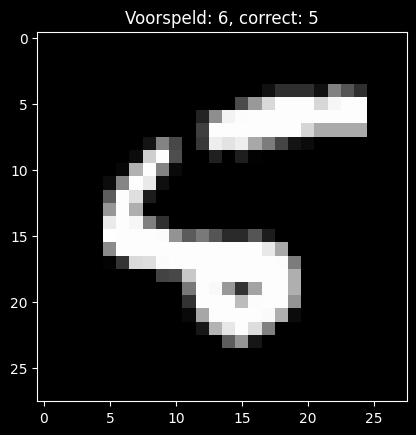

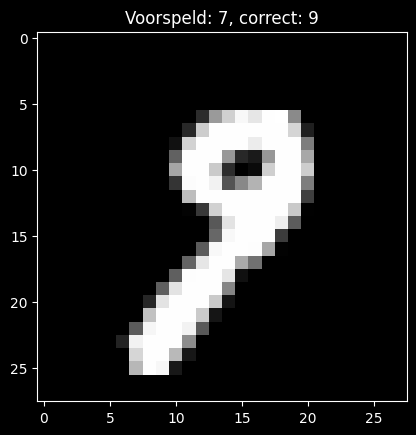

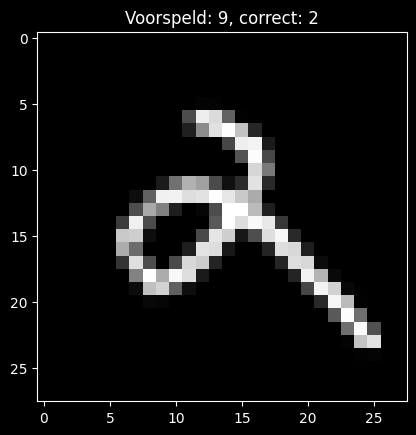

In [46]:
model = train_model(input_size, hidden_size, output_size, x_train, y_train)
test_model(model, input_size, output_size, x_test, y_test)

## (optioneel) 9. Meerdere verborgen lagen

Pas de code zo aan dat het neurale netwerk 2 verborgen lagen heeft. Hoe groot moeten de verborgen lagen nu minimaal zijn?